In [1]:
import pandas as pd

df = pd.read_csv('../data/Service Requests and Complaints since 2023.csv')
df.head()

,_id,Activity Year,Mobile_Enforcement,SR Type
0,1,2025,MOBILE RESPONSE SERVICE REQUESTS,CADAVER - WILDLIFE
1,2,2025,MOBILE RESPONSE SERVICE REQUESTS,INJURED WILDLIFE
2,3,2025,MOBILE RESPONSE SERVICE REQUESTS,COYOT RESPONSE
3,4,2025,MOBILE RESPONSE SERVICE REQUESTS,INJURED DOMESTIC
4,5,2025,MOBILE RESPONSE SERVICE REQUESTS,COYOT RESPONSE


In [2]:
print("Dataset Info:")
df.info()

print("\nMissing Values:")
print(df.isna().sum())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 196973 entries, 0 to 196972
Data columns (total 4 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   _id                 196973 non-null  int64
 1   Activity Year       196973 non-null  int64
 2   Mobile_Enforcement  196973 non-null  str  
 3   SR Type             196961 non-null  str  
dtypes: int64(2), str(2)
memory usage: 6.0 MB

Missing Values:
_id                    0
Activity Year          0
Mobile_Enforcement     0
SR Type               12
dtype: int64


In [3]:
df_clean = df.dropna(subset=['SR Type'])

print(f"Original row count: {len(df)}")
print(f"Cleaned row count: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")

Original row count: 196973
Cleaned row count: 196961
Rows removed: 12


In [4]:
yearly_volume = df_clean['Activity Year'].value_counts().sort_index()

print("Service Requests per Year:")
print(yearly_volume)

Service Requests per Year:
Activity Year
2023    50795
2024    57295
2025    55470
2026    33401
Name: count, dtype: int64


In [5]:
workload_split = df_clean['Mobile_Enforcement'].value_counts()

workload_percentages = df_clean['Mobile_Enforcement'].value_counts(normalize=True) * 100

print("Workload Split (Total Cases):")
print(workload_split)
print("\nWorkload Split (Percentage):")
print(workload_percentages.round(2))

Workload Split (Total Cases):
Mobile_Enforcement
MOBILE RESPONSE SERVICE REQUESTS    157414
ENFORCEMENT COMPLAINTS               39547
Name: count, dtype: int64

Workload Split (Percentage):
Mobile_Enforcement
MOBILE RESPONSE SERVICE REQUESTS    79.92
ENFORCEMENT COMPLAINTS              20.08
Name: proportion, dtype: float64


Matplotlib is building the font cache; this may take a moment.


Top 10 Service Request Types:
SR Type
INJURED WILDLIFE              65098
CADAVER - WILDLIFE            56715
COYOT RESPONSE                14751
NOISE                          8371
AN TO HU                       6936
STRAY ANIMAL CONFINED          5375
STRAY DOG RUNNING AT LARGE     4756
CADAVER - DOMESTIC             4625
INJURED DOMESTIC               3726
NO LEASH                       3152
Name: count, dtype: int64


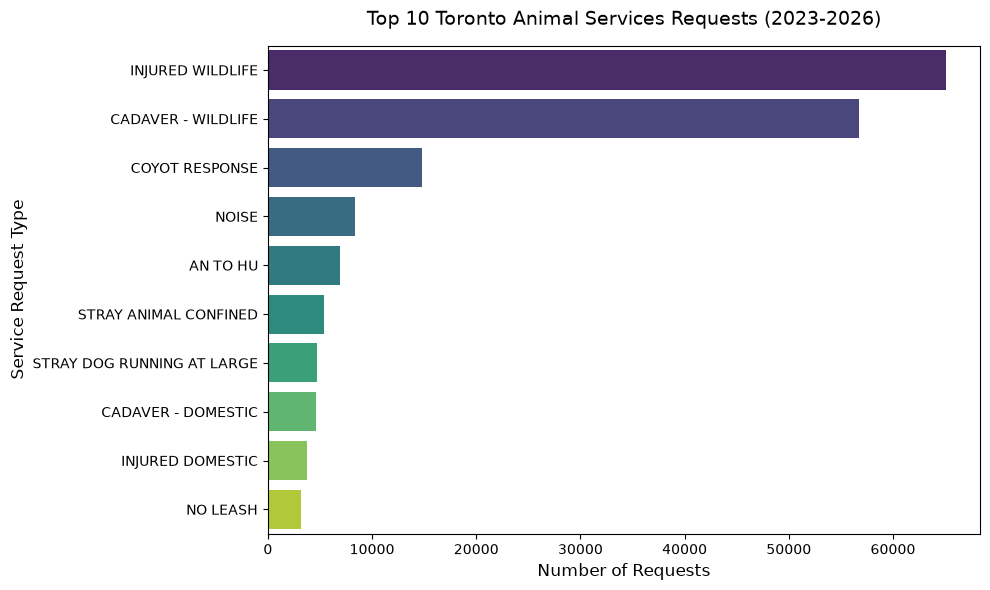

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

top_10_sr = df_clean['SR Type'].value_counts().head(10)

print("Top 10 Service Request Types:")
print(top_10_sr)

plt.figure(figsize=(10, 6))

sns.barplot(x=top_10_sr.values, y=top_10_sr.index, hue=top_10_sr.index, palette='viridis', legend=False)

plt.title("Top 10 Toronto Animal Services Requests (2023-2026)", fontsize=14, pad=15)
plt.xlabel("Number of Requests", fontsize=12)
plt.ylabel("Service Request Type", fontsize=12)
plt.tight_layout()

plt.savefig('../outputs/figures/top_10_requests_chart.png')
plt.show()

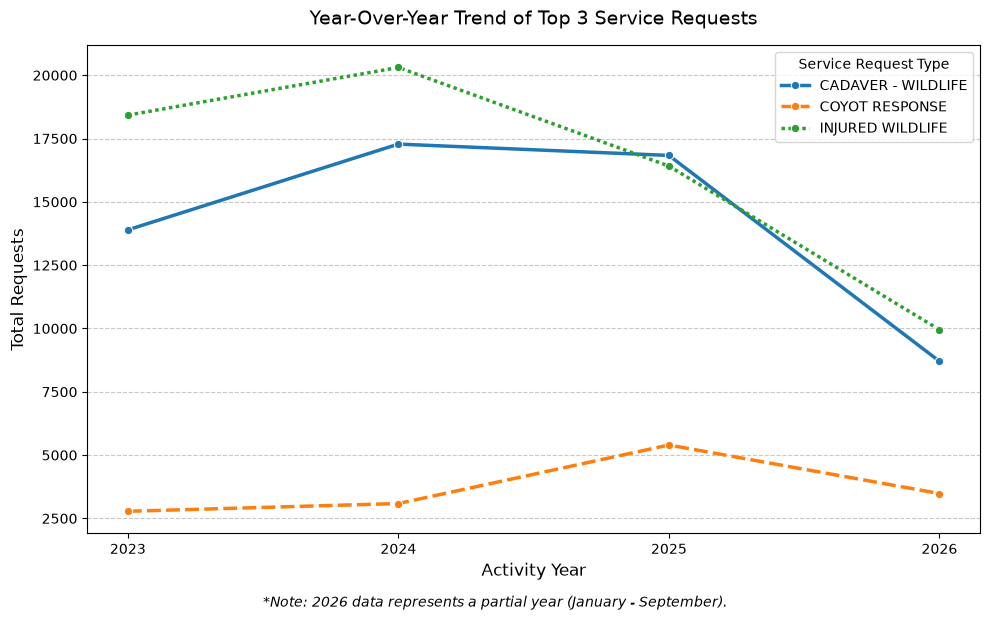

In [10]:
top_3_types = df_clean['SR Type'].value_counts().head(3).index
trend_data = df_clean[df_clean['SR Type'].isin(top_3_types)]

yearly_trends = trend_data.groupby(['Activity Year', 'SR Type']).size().unstack()

plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly_trends, marker='o', palette='tab10', linewidth=2.5)

plt.title("Year-Over-Year Trend of Top 3 Service Requests", fontsize=14, pad=15)
plt.xlabel("Activity Year", fontsize=12)
plt.ylabel("Total Requests", fontsize=12)
plt.xticks([2023, 2024, 2025, 2026]) 
plt.legend(title="Service Request Type")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.figtext(0.5, -0.02, "*Note: 2026 data represents a partial year (January - September).", ha="center", fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('../outputs/figures/top_3_trends_chart.png', bbox_inches="tight")
plt.show()

In [12]:
yoy_change = yearly_trends.pct_change() * 100

print("Year-over-Year Percentage Change (2024 to 2025):")
print(yoy_change.loc[2025].round(1).astype(str) + '%')

Year-over-Year Percentage Change (2024 to 2025):
SR Type
CADAVER - WILDLIFE     -2.6%
COYOT RESPONSE         74.8%
INJURED WILDLIFE      -19.2%
Name: 2025, dtype: str


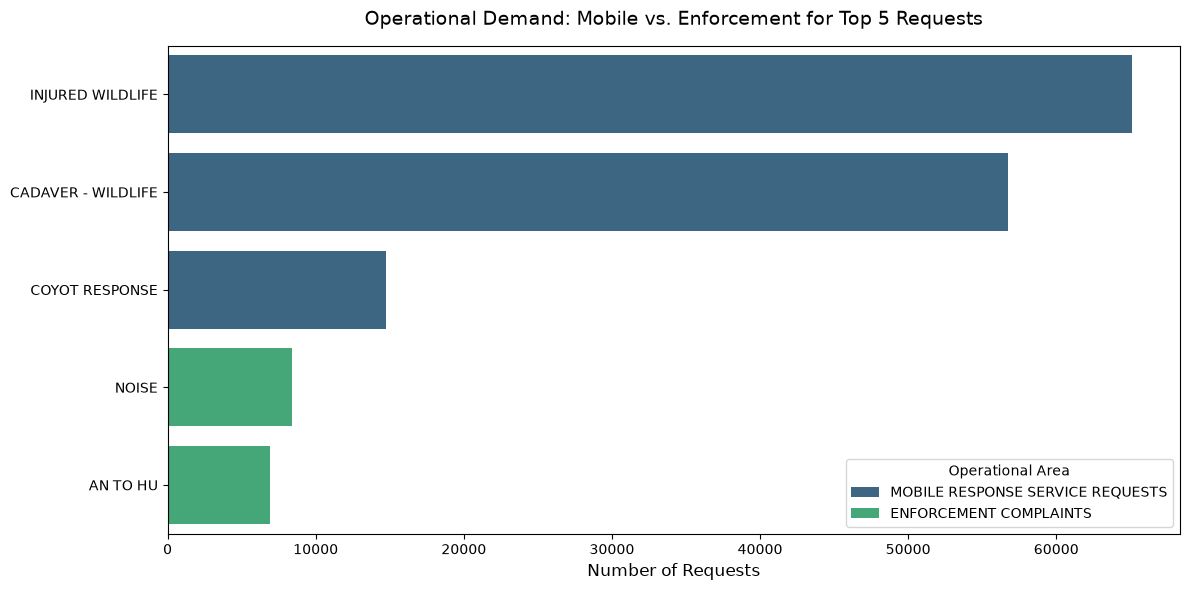

In [11]:
top_5_sr = df_clean['SR Type'].value_counts().head(5).index

df_top_5 = df_clean[df_clean['SR Type'].isin(top_5_sr)]

plt.figure(figsize=(12, 6))
sns.countplot(data=df_top_5, y='SR Type', hue='Mobile_Enforcement', order=top_5_sr, palette='viridis')

plt.title("Operational Demand: Mobile vs. Enforcement for Top 5 Requests", fontsize=14, pad=15)
plt.xlabel("Number of Requests", fontsize=12)
plt.ylabel("")
plt.legend(title="Operational Area", loc='lower right')
plt.tight_layout()

plt.savefig('../outputs/figures/mobile_vs_enforcement_chart.png')
plt.show()